# Define MLD and pycnocline layer

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38759")
client

<Client: 'tcp://127.0.0.1:38759' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Calculate potential density

In [18]:
# Convert depth (m) to pressure (dbar)
p = gsw.p_from_z(HH_grid.Z, 70)  # Depth is negative

# Convert Practical Salinity (SP) to Absolute Salinity (SA)
SA = gsw.SA_from_SP(salt_day, p, salt_day.XC, salt_day.YC)  # Assume longitude = 0 if unknown

# Convert Potential Temperature to Conservative Temperature
CT = gsw.conversions.CT_from_pt(SA, theta_day)

# Calculate potential density anomaly referenced to 0 dbar (1000 is subtracted)
sigma0 = gsw.sigma0(SA, CT)

In [19]:
sigma0.name = 'potential_density'
sigma0.attrs['long_name'] = 'potential_density'

### Select three points

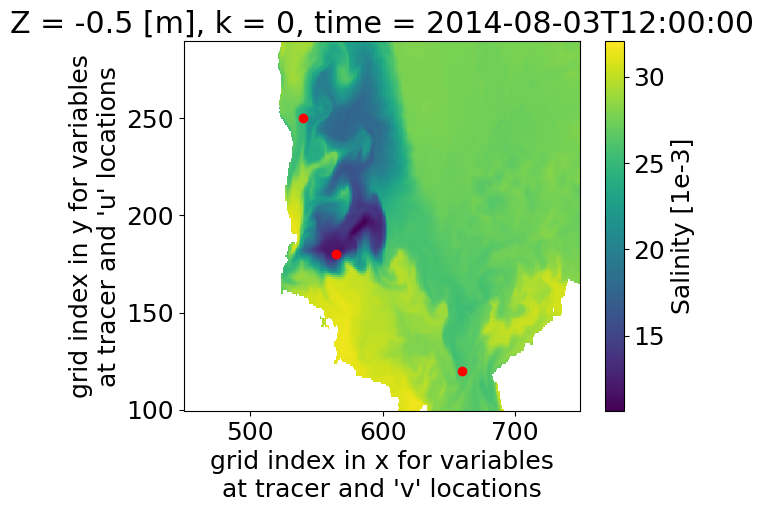

In [20]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

### Calculate MLD

#### Test with one profile

In [21]:
sigma0_tmp = sigma0.isel(time=350, i=540, j=250)

In [22]:
# identify the maximum depth at which the density is within a certain threshold of the shallowest measured density 
# take density from uppermost grid cell
rho_Z0 = sigma0_tmp.isel(k=0)

In [23]:
# add threshold
density_threshold = 0.03 # kg m^-3
# density_threshold = 0.1 # kg m^-3
threshold = (rho_Z0 + density_threshold)

In [24]:
# subtract threshold from density profiles
density_minus_threshold = abs(sigma0_tmp-threshold)

In [25]:
# identify index for where density exceeds threshold
threshold_idx = density_minus_threshold.argmin(dim='k',skipna=True)

In [26]:
# extract depth where density exceeds threshold (=MLD)
MLD_prof = sigma0_tmp.isel(k=threshold_idx.compute()).Z

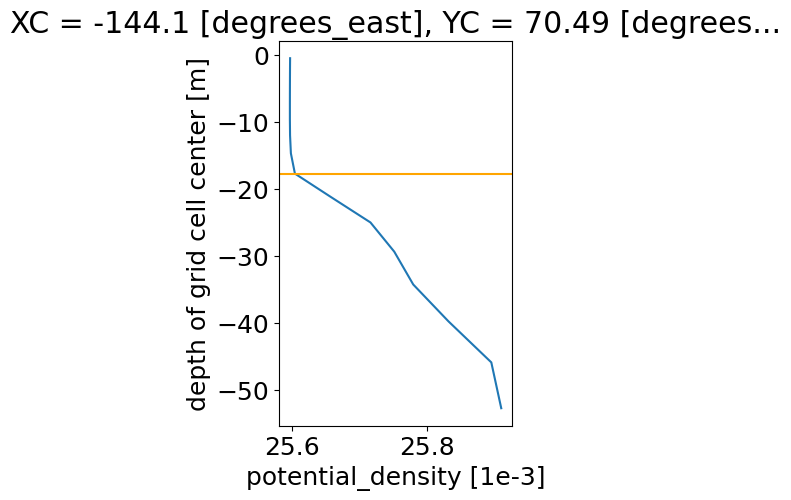

In [27]:
sigma0.isel(time=350, i=540, j=250).plot(y='Z',figsize=[3,5]);
plt.axhline(y=MLD_prof,color='orange');

In [100]:
import matplotlib.pyplot as plt

def plot_profile(date, theta_day, salt_day, density_day, threshold=0.03, i=565, j=180):
    """
    Plots temperature and salinity profiles for a single date with solid lines,
    with salinity as a secondary axis on the temperature plot, and density on a separate axis.
    Includes a horizontal line for the Mixed Layer Depth (MLD).
    """
    
    # Create figure and subplots
    plt.rcParams['font.size'] = 18
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 6], sharey=True)

    # Extract data for the given date
    theta = theta_day.sel(time=date).isel(i=i, j=j, time=0)
    salt = salt_day.sel(time=date).isel(i=i, j=j, time=0)
    density = density_day.sel(time=date).isel(i=i, j=j, time=0)
    
    # Compute MLD based on density threshold
    rho_Z0 = density.isel(k=0)  # Density at the shallowest level
    density_threshold = threshold  # kg/m³
    threshold = rho_Z0 + density_threshold
    density_minus_threshold = abs(density - threshold)
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    MLD_prof = density.isel(k=threshold_idx.compute()).Z
    
    # Plot temperature profile
    theta.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='solid')
    ax1.tick_params(axis='x', colors='tab:blue')

    # Add salinity profile as a secondary axis
    ax1_sec = ax1.twiny()
    salt.plot(ax=ax1_sec, y='Z', color='tab:red', marker='.', linestyle='solid')
    ax1_sec.tick_params(axis='x', colors='tab:red')
    
    # Plot density profile
    density.plot(ax=ax2, y='Z', color='black', marker='.', linestyle='solid')
    ax2.axhline(y=MLD_prof, color='tab:orange', linewidth=1.5, linestyle='dashed', label="MLD")
    ax2.legend(fontsize=12)
    
    # Formatting axes
    for ax in (ax1, ax1_sec, ax2):
        ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        ax.set_title("")
    
    # Add labels
    ax1.set_xlabel("$\Theta$ ($\degree$C)", color='tab:blue')
    ax1_sec.set_xlabel("$S_A$ (g/kg)", color='tab:red')
    ax1.set_ylabel("Depth (m)")
    ax2.set_ylabel("")
    ax2.set_xlabel(r"$\sigma_{\theta}$ (kg/m³)")

    # # west of plume
    # ax1.set_xlim(-2,5)
    # ax1.set_xticks([-2, 0, 2, 4])
    # ax1_sec.set_xlim(28,32.5)
    # ax1_sec.set_xticks([28, 30, 32.5])
    # ax2.set_xlim(23,25.61)
    
    # # inside plume
    # ax1.set_xlim(-2,5.2)
    # ax1.set_xticks([-2, 0, 2, 4])
    # ax1_sec.set_xlim(5,35)
    # ax1_sec.set_xticks([5, 20, 35])
    # ax2.set_xlim(5,26)
    
    # northeast of plume
    ax1.set_xlim(-2,5)
    ax1.set_xticks([-2, 0, 2, 4])
    ax1_sec.set_xlim(27,32.5)
    ax1_sec.set_xticks([27, 30, 32])
    ax2.set_xlim(22,26)
    
    # Add a title to the whole figure
    fig.suptitle(f"Grid cell [i={i}, j={j}]\n{date}", fontsize=14, y=1.05)
    
    # Show the plot
    plt.show()

#### West of Mackenzie

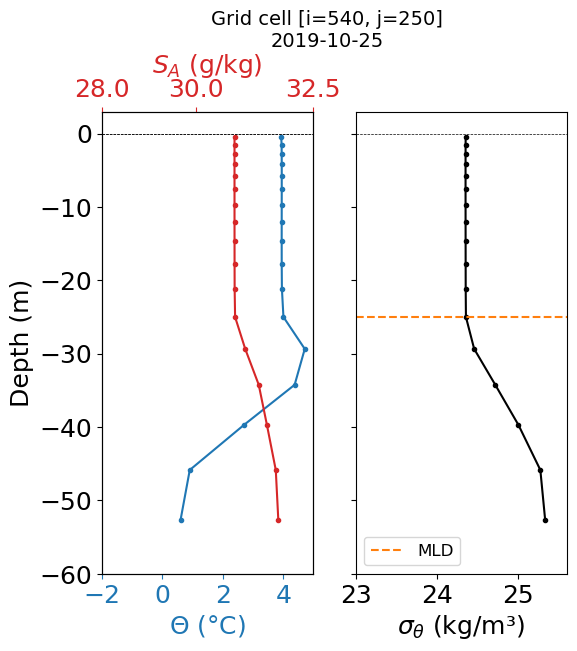

In [54]:
plot_profile("2019-10-25", CT, SA, sigma0, threshold=0.03, i=540, j=250)

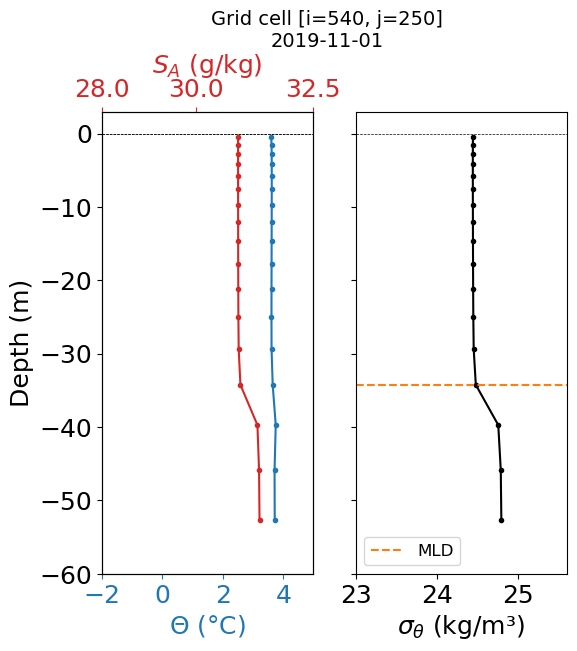

In [55]:
# 7 days before SI>0
plot_profile("2019-11-01", CT, SA, sigma0, threshold=0.03, i=540, j=250)

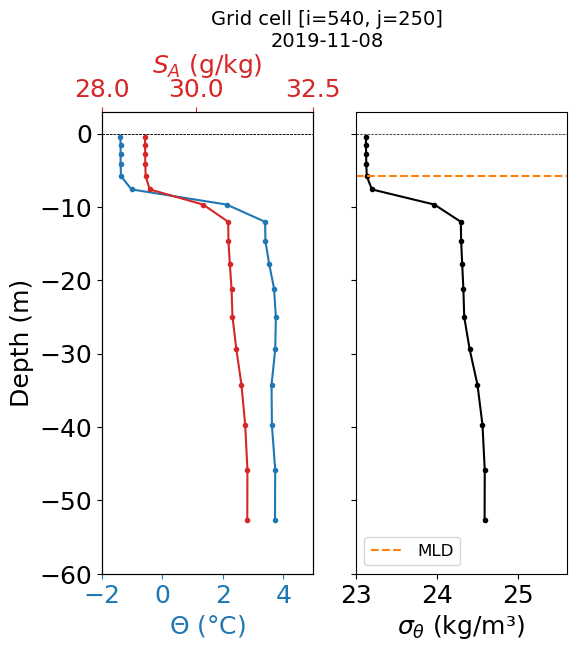

In [56]:
# SI>0
plot_profile("2019-11-08", CT, SA, sigma0, threshold=0.03, i=540, j=250)

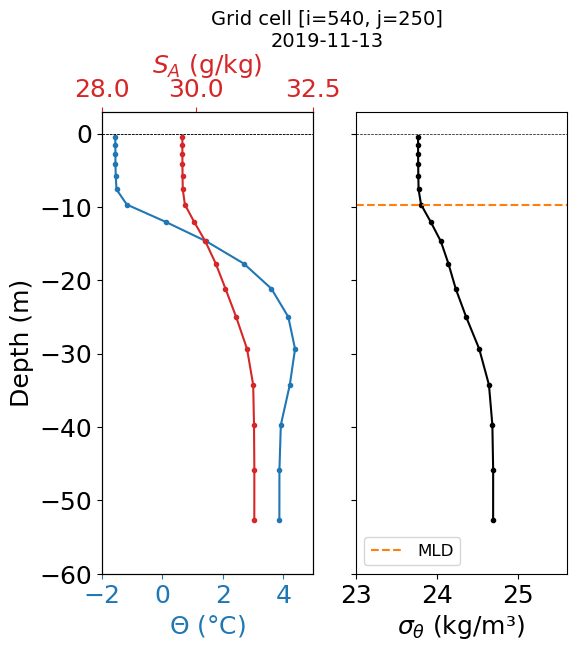

In [57]:
# SI>=15
plot_profile("2019-11-13", CT, SA, sigma0, threshold=0.03, i=540, j=250)

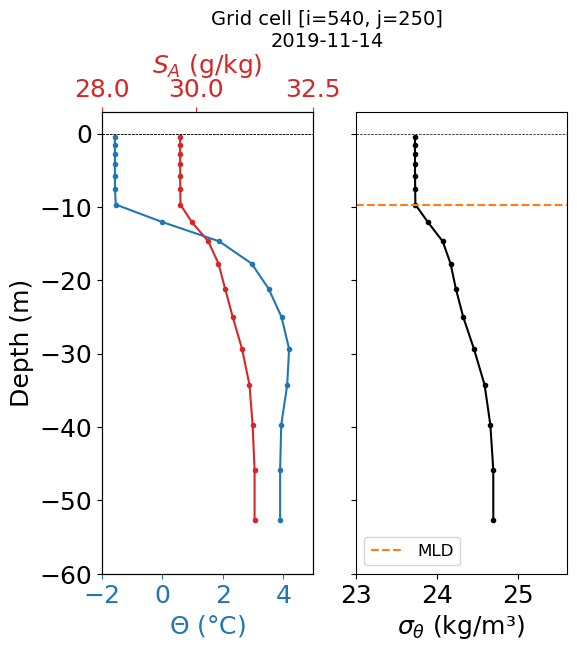

In [58]:
# SI>=50
plot_profile("2019-11-14", CT, SA, sigma0, threshold=0.03, i=540, j=250)

#### Within Mackenzie

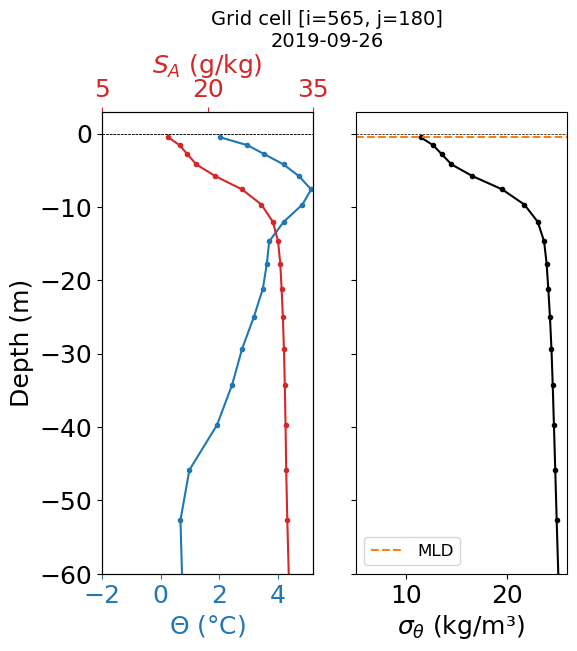

In [62]:
# 14 days before SI>0
plot_profile("2019-09-26", CT, SA, sigma0, threshold=0.03, i=565, j=180)

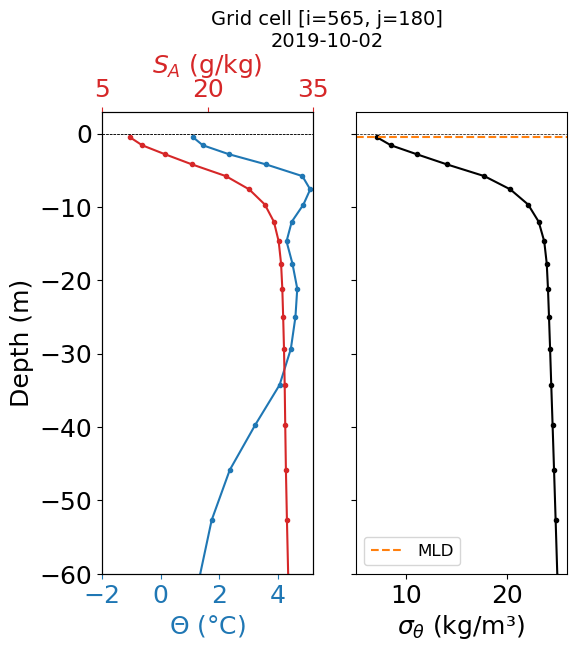

In [63]:
# 7 days before SI>0
plot_profile("2019-10-02", CT, SA, sigma0, threshold=0.03, i=565, j=180)

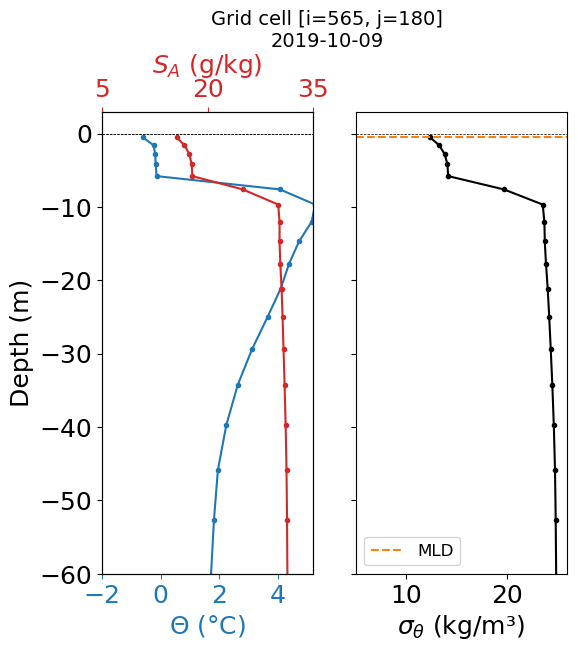

In [64]:
# SI>0
plot_profile("2019-10-09", CT, SA, sigma0, threshold=0.03, i=565, j=180)

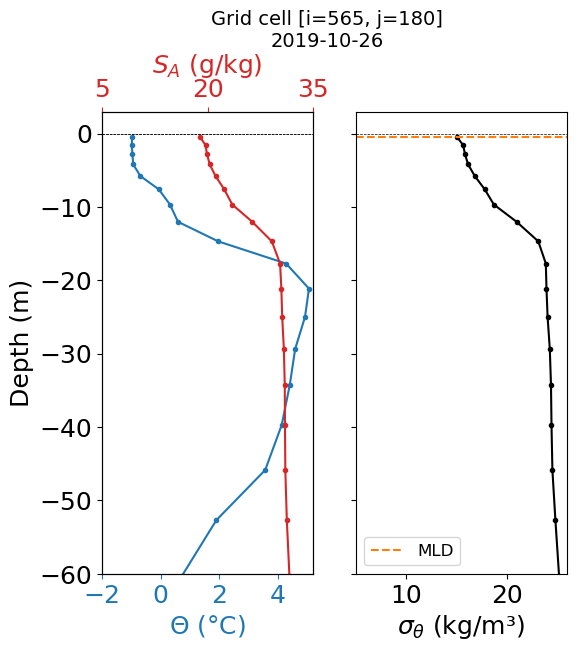

In [65]:
# SI>=15%
plot_profile("2019-10-26", CT, SA, sigma0, threshold=0.03, i=565, j=180)

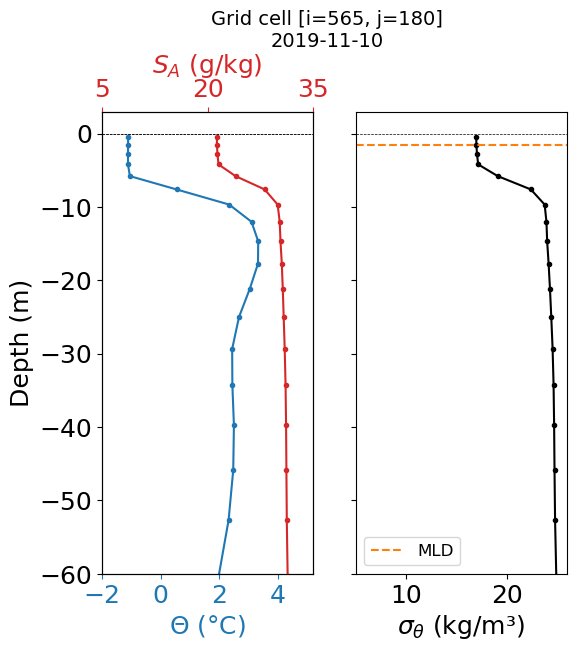

In [74]:
# SI>=50%
plot_profile("2019-11-10", CT, SA, sigma0, threshold=0.03, i=565, j=180)

#### NE of Mackenzie

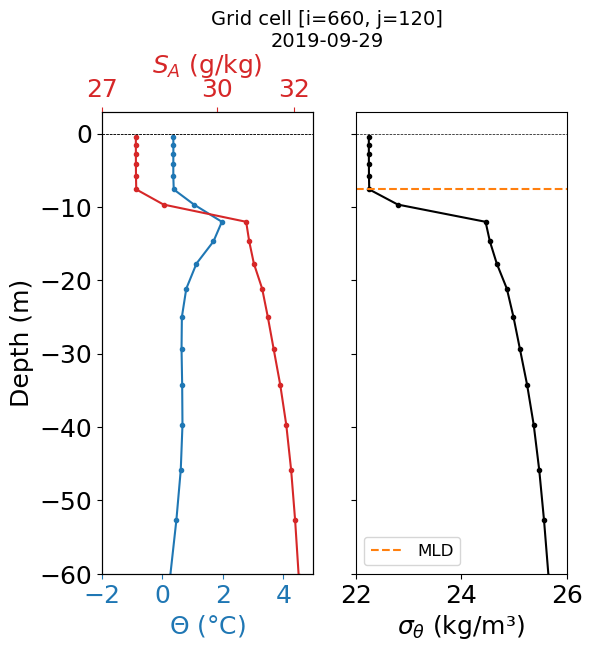

In [101]:
# 14 days before SI>0
plot_profile("2019-09-29", CT, SA, sigma0, threshold=0.03, i=660, j=120)

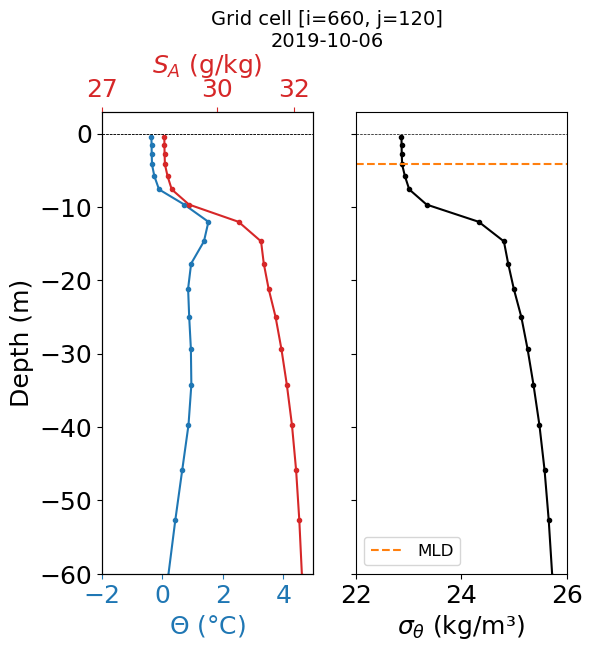

In [102]:
# 7 days before SI>0
plot_profile("2019-10-06", CT, SA, sigma0, threshold=0.03, i=660, j=120)

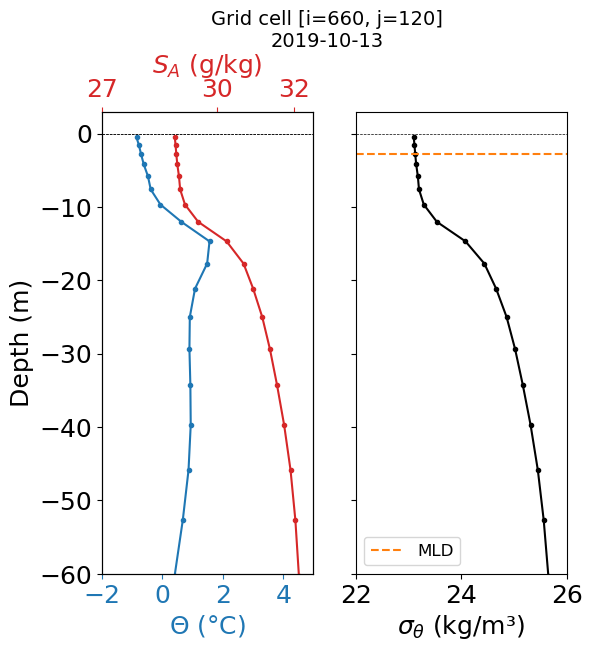

In [103]:
# SI>0
plot_profile("2019-10-13", CT, SA, sigma0, threshold=0.03, i=660, j=120)

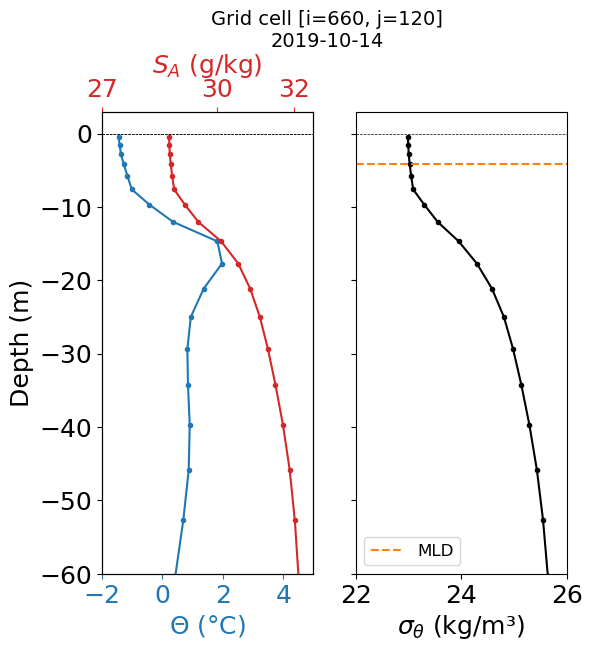

In [104]:
# SI>=15%
plot_profile("2019-10-14", CT, SA, sigma0, threshold=0.03, i=660, j=120)

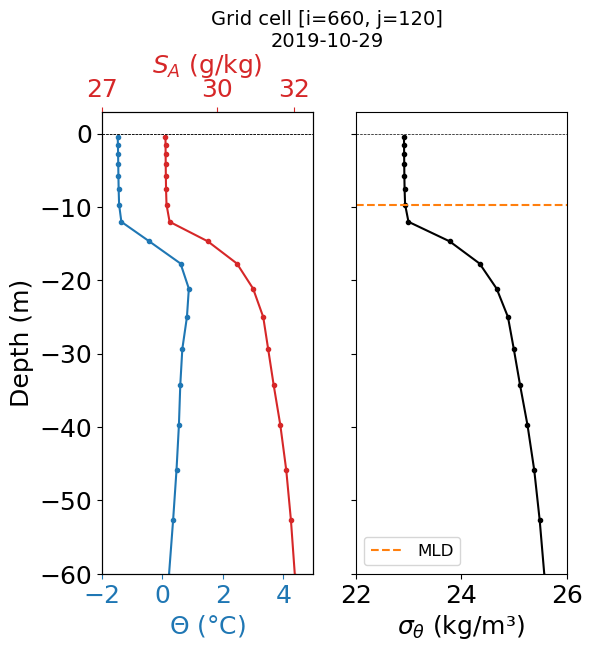

In [105]:
# SI>=50%
plot_profile("2019-10-29", CT, SA, sigma0, threshold=0.03, i=660, j=120)

### Plot map of SSS

In [226]:
date = '2019-09-15'

In [227]:
# select just beaufort region
sigma0_beaufort = sigma0.sel(time=date).isel(time=0,i=slice(450,750),j=slice(70,390))
SSS_beaufort = SA.sel(time=date).isel(time=0,k=0,i=slice(450,750),j=slice(70,390))
SST_beaufort = CT.sel(time=date).isel(time=0,k=0,i=slice(450,750),j=slice(70,390))
SIC_beaufort = ice_day.sel(time=date).isel(time=0,i=slice(450,750),j=slice(70,390))

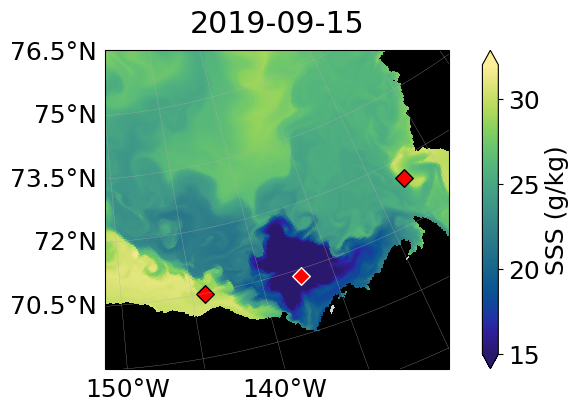

In [235]:
fig = plt.figure(figsize=(8,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude = -155))
ax1.set_extent([-150, -128, 69, 75], ccrs.PlateCarree())

HH_grid_land.plot(x='XC',y='YC',ax=ax1,vmin=0,vmax=1,cmap='grey',transform=ccrs.PlateCarree(),add_colorbar=False)
cbar_mld = SSS_beaufort.plot(x='XC',y='YC',ax=ax1,vmin=15,vmax=32,cmap=cmocean.cm.haline,transform=ccrs.PlateCarree(),cbar_kwargs={'label': 'SSS (g/kg)'});

ax1.set_facecolor('lightgray')
gl = ax1.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2,draw_labels=True,x_inline=False, y_inline=False,\
                  xpadding=6,ypadding=6,rotate_labels=False)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True

# add points for selected profiles with black outlines
ax1.scatter(HH_grid.isel(i=565,j=180).XC.values, HH_grid.isel(i=565,j=180).YC.values,
            c='r', edgecolors='white', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=540,j=250).XC.values, HH_grid.isel(i=540,j=250).YC.values,
            c='r', edgecolors='k', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=660,j=120).XC.values, HH_grid.isel(i=660,j=120).YC.values,
            c='r', edgecolors='k', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.set_title(date);

In [ ]:
# Create a mask for locations where k=0 is NaN
surface_nan_mask = sigma0_beaufort.isel(k=0,time=0).isnull()

# Replace NaNs in the dataset with zero for calculations
sigma0_filled = sigma0_beaufort.fillna(0)

# Compute surface density
rho_Z0 = sigma0_filled.isel(k=0)

# Compute threshold density
density_threshold = 0.03
threshold = (rho_Z0 + density_threshold).values

# Compute absolute difference from threshold
density_minus_threshold = abs(sigma0_filled - threshold)

# Find the index of the minimum difference, skipping NaNs
threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)

# Extract the corresponding depth value for MLD
MLD = sigma0_beaufort.isel(k=threshold_idx.compute()).Z

# Mask out grid cells where k=0 was originally NaN
MLD = MLD.where(~surface_nan_mask, float('nan'))

In [ ]:
fig = plt.figure(figsize=(8,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo(central_longitude = -155))
ax1.set_extent([-150, -128, 69, 75], ccrs.PlateCarree())

HH_grid_land.plot(x='XC',y='YC',ax=ax1,vmin=0,vmax=1,cmap='grey',transform=ccrs.PlateCarree(),add_colorbar=False)
cbar_mld = MLD.plot(x='XC',y='YC',ax=ax1,vmin=-20,vmax=0,cmap='turbo',transform=ccrs.PlateCarree(),cbar_kwargs={'label': 'MLD (m)'});

ax1.set_facecolor('lightgray')
# ax1.set_title("depth=" + str(theta_350m.depth.values))
gl = ax1.gridlines(crs=ccrs.PlateCarree(), linewidth=0.2,draw_labels=True,x_inline=False, y_inline=False,\
                  xpadding=6,ypadding=6,rotate_labels=False)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True

# add points for selected profiles with black outlines
ax1.scatter(HH_grid.isel(i=565,j=180).XC.values, HH_grid.isel(i=565,j=180).YC.values,
            c='white', edgecolors='black', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=540,j=250).XC.values, HH_grid.isel(i=540,j=250).YC.values,
            c='white', edgecolors='black', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.scatter(HH_grid.isel(i=660,j=120).XC.values, HH_grid.isel(i=660,j=120).YC.values,
            c='white', edgecolors='black', marker='D', s=80, transform=ccrs.PlateCarree());

ax1.set_title(date);

### Plot map of MLD, SSS, SST, and SIC

In [237]:
# select just beaufort region and Sept 15 for each year
sigma0_beaufort = sigma0.sel(time=sigma0['time'].dt.strftime('%m-%d') == '09-15').isel(i=slice(450,750),j=slice(70,390))
SSS_beaufort = SA.sel(time=SA['time'].dt.strftime('%m-%d') == '09-15').isel(k=0,i=slice(450,750),j=slice(70,390))
SST_beaufort = CT.sel(time=CT['time'].dt.strftime('%m-%d') == '09-15').isel(k=0,i=slice(450,750),j=slice(70,390))
SIC_beaufort = ice_day.sel(time=ice_day['time'].dt.strftime('%m-%d') == '09-15').isel(i=slice(450,750),j=slice(70,390))

In [239]:
MLD_all_time = []  # List to store MLD for each timestep

for t in range(len(sigma0_beaufort.time)):
    # Create a mask for locations where k=0 is NaN
    surface_nan_mask = sigma0_beaufort.isel(k=0, time=t).isnull()

    # Replace NaNs in the dataset with zero for calculations
    sigma0_filled = sigma0_beaufort.fillna(0)

    # Compute surface density
    rho_Z0 = sigma0_filled.isel(k=0, time=t)

    # Compute threshold density
    density_threshold = 0.03
    threshold = (rho_Z0 + density_threshold).values

    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_filled.isel(time=t) - threshold)

    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)

    # Extract the corresponding depth value for MLD
    MLD = sigma0_beaufort.isel(k=threshold_idx.compute(), time=t).Z

    # Mask out grid cells where k=0 was originally NaN
    MLD = MLD.where(~surface_nan_mask, float('nan'))

    # Store in the list
    MLD_all_time.append(MLD)

# Combine the results into a single xarray DataArray
MLD_all_time = xr.concat(MLD_all_time, dim='time')
MLD_all_time = MLD_all_time.assign_coords(time=sigma0_beaufort.time)

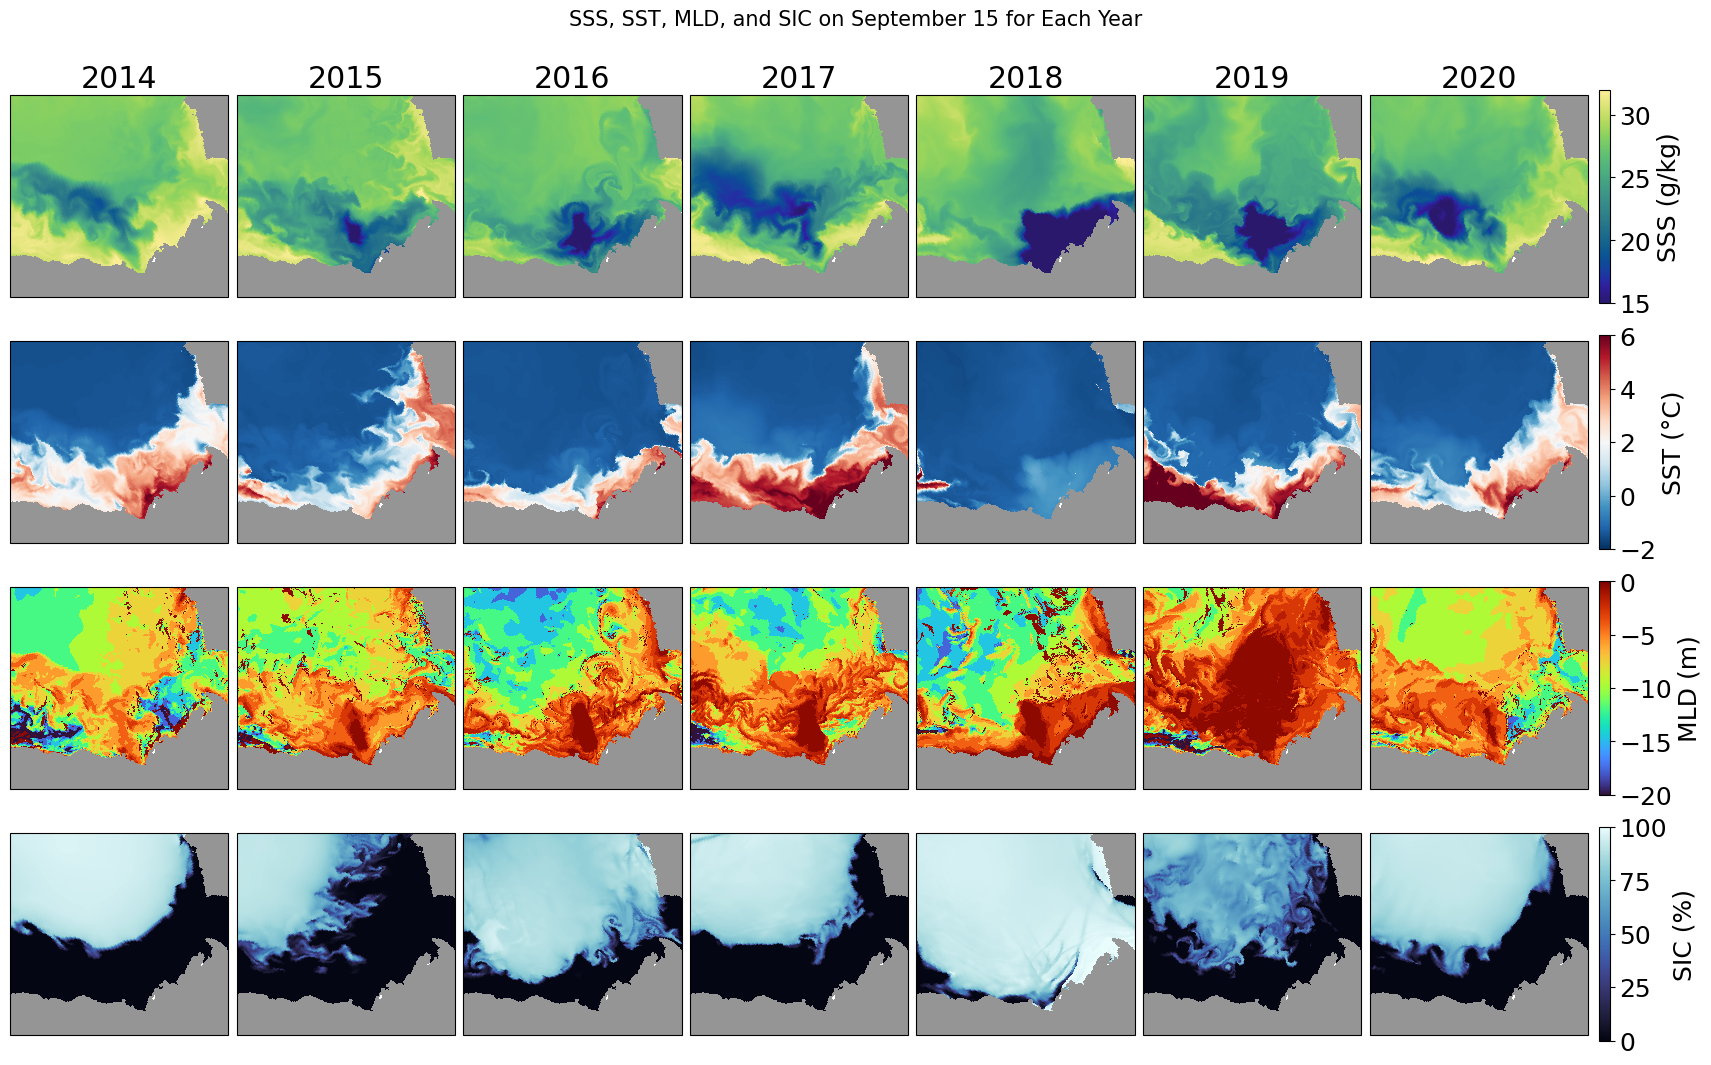

In [241]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(4, 7, figsize=(17, 10), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 32
vmin_SST = -2
vmax_SST = 6
vmin_MLD = -20
vmax_MLD = 0
vmin_SIC = 0
vmax_SIC = 100

# Loop through each year and plot all variables
for year in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.haline, vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    
    # SST (Row 2)
    ax = axes[1, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SST_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='RdBu_r', vmin=vmin_SST, vmax=vmax_SST, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")

    # MLD (Row 3)
    ax = axes[2, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    MLD_all_time.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_MLD, vmax=vmax_MLD, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
    # SIC (Row 4)
    ax = axes[3, year]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SIC_beaufort.isel(time=year).plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.ice, vmin=vmin_SIC, vmax=vmax_SIC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline, vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('RdBu_r', vmin_SST, vmax_SST, 'SST (°C)'),
    ('turbo', vmin_MLD, vmax_MLD, 'MLD (m)'),
    (cmocean.cm.ice, vmin_SIC, vmax_SIC, 'SIC (%)')
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS, SST, MLD, and SIC on September 15 for Each Year', fontsize=15, y=1.05);

In [137]:
import xarray as xr

def calculate_mld(density_profiles, density_threshold=0.03):
    """
    Calculates the Mixed Layer Depth (MLD) for a 3D density profile (depth, lat, lon)
    based on a density threshold method.
    
    Parameters:
    - density_profiles: 3D xarray DataArray of density values (depth, lat, lon).
    - depth_levels: 1D xarray DataArray of corresponding depth values.
    - density_threshold: Density increase threshold from surface (default: 0.03 kg/m³).
    
    Returns:
    - MLD: 2D xarray DataArray (lat, lon) where each grid point has an MLD value,
           or NaN where the profile contains all NaNs.
    """
    
    # Check if entire profiles are NaN and mask them
    nan_mask = density_profiles.isnull().all(dim='k')
    
    # Compute surface density
    rho_Z0 = density_profiles.isel(k=0)
    
    # Compute threshold density
    threshold = rho_Z0 + density_threshold
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(density_profiles - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k')

    # Extract the corresponding depth value for MLD
    MLD = density_profiles.isel(k=threshold_idx).Z
    
    # Apply NaN mask to remove invalid MLD values
    MLD = MLD.where(~nan_mask, float('nan'))
    
    return threshold_idx, density_minus_threshold

In [139]:
mld_beaufort_tmp, density_minus_threshold = calculate_mld(sigma0_beaufort, density_threshold=0.03)

check
